# Algorytm Incremental

In [1]:
%run interface.ipynb
%run tests.ipynb

### Algorytm bez wizualizacji

In [2]:
def orient(a, b, c):
    # Określa orientację punktów (a, b, c)
    result = a.x * b.y + b.x * c.y + a.y * c.x - c.x * b.y - b.x * a.y - a.x * c.y
    
    if result > 10e-12:
        return 1  # Przeciwnie do ruchu wskazówek zegara
    elif result < -10e-12:
        return -1 # Zgodnie z ruchem wskazówek zegara
    else:
        return 0  # Współliniowe

In [3]:
def incremental(points):
    sorted_points = sorted(points, key = lambda point: (point.x, point.y))

    hull = []
    if orient(sorted_points[0], sorted_points[1], sorted_points[2]) >= 0:
        hull.append(sorted_points[0])
        hull.append(sorted_points[1])
        hull.append(sorted_points[2])
    elif orient(sorted_points[0], sorted_points[1], sorted_points[2]) == -1:
        hull.append(sorted_points[0])
        hull.append(sorted_points[2])
        hull.append(sorted_points[1])

    for i in range(3, len(sorted_points)):
        n = len(hull)
        point = sorted_points[i]

        upper_point_index = n - 1
        lower_point_index = n - 1

        while orient(point, hull[upper_point_index], hull[(upper_point_index + 1) % n]) <= 0:
            upper_point_index = (upper_point_index + 1) % n

        while orient(point, hull[lower_point_index], hull[(lower_point_index - 1 + n) % n]) >= 0:
            lower_point_index = (lower_point_index - 1 + n) % n

        new_hull = []
        current_index = upper_point_index
        new_hull.append(hull[upper_point_index])

        while current_index != lower_point_index:
            current_index = (current_index + 1) % n
            new_hull.append(hull[current_index])
        new_hull.append(point)

        hull = new_hull[::]

    return hull

### Testy poprawności

In [4]:
run_test(incremental)

Test 1:
	Czas: 0.0s
	Wynik: NIEPOPRAWNY
	Oczekiwano:
	 [Point(1, 1), Point(10, 1), Point(10, 10), Point(1, 10)]
	Otrzymano:
	 [Point(1, 10), Point(1, 1), Point(10, 1), Point(10, 10)]
Test 2:
	Czas: 0.001s
	Wynik: NIEPOPRAWNY
	Oczekiwano:
	 [Point(26.99983489084225, -99.82787980408634), Point(49.4875684177654, -96.98546763401905), Point(86.86938616644139, -89.774442065276), Point(97.03023087264094, -54.2732564291647), Point(97.98243950777251, -7.247447257755567), Point(99.62429973830214, 90.45367284754775), Point(99.51580185367374, 98.5358498628375), Point(-5.837289230972402, 98.83691118752364), Point(-40.29957629237933, 98.47537052300748), Point(-90.38656693287955, 94.99371630110286), Point(-97.04434825584222, 31.491368438355153), Point(-99.10643180807772, -97.51964697896445)]
	Otrzymano:
	 [Point(99.51580185367374, 98.5358498628375), Point(-5.837289230972402, 98.83691118752364), Point(-40.29957629237933, 98.47537052300748), Point(-90.38656693287955, 94.99371630110286), Point(-97.04434

KeyboardInterrupt: 

### Zadawanie zbioru punktów

In [ ]:
run_time_tests(incremental)

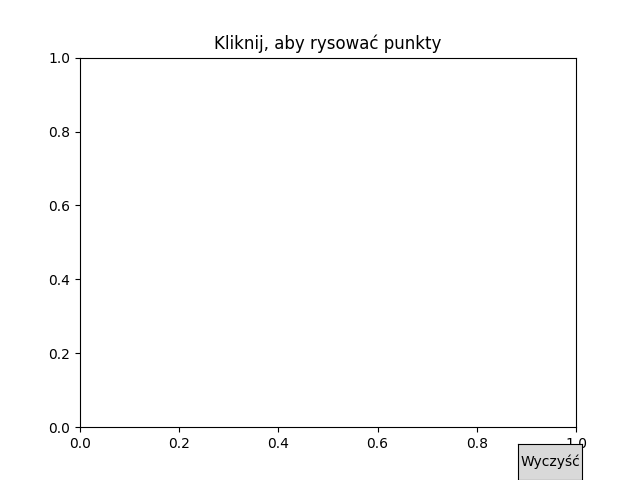

In [23]:
polygon = PolygonDrawer()

### Algorytm wraz z wizualizacją

In [71]:
def incremental_visual(points):
    visualizer = ConvexHullVisualizer()
    sorted_points = sorted(points, key=lambda point: (point.x, point.y))

    hull = []

    if orient(sorted_points[0], sorted_points[1], sorted_points[2]) >= 0:
        hull.extend([sorted_points[0], sorted_points[1], sorted_points[2]])
    else:
        hull.extend([sorted_points[0], sorted_points[2], sorted_points[1]])

    visualizer.add_frame(points, [hull], [], [], None)

    for i in range(3, len(sorted_points)):
        point = sorted_points[i]
        n = len(hull)

        upper_point_index = n - 1
        lower_point_index = n - 1
        
        while orient(point, hull[upper_point_index], hull[(upper_point_index + 1) % n]) <= 0:
            upper_point_index = (upper_point_index + 1) % n

        while orient(point, hull[lower_point_index], hull[(lower_point_index - 1 + n) % n]) >= 0:
            lower_point_index = (lower_point_index - 1 + n) % n

        visualizer.add_frame(points, [hull], [], [Segment(hull[upper_point_index], point), Segment(hull[lower_point_index], point)], point)  
        
        new_hull = []
        current_index = upper_point_index
        new_hull.append(hull[upper_point_index])

        while current_index != lower_point_index:
            current_index = (current_index + 1) % n
            new_hull.append(hull[current_index])

        new_hull.append(point)
        hull = new_hull[::]

        visualizer.add_frame(points, [hull], [], [], point)

    display(visualizer.create_animation())


In [72]:
incremental_visual(polygon.points)